<a href="https://colab.research.google.com/github/LukaM286/movie-success-prediction/blob/main/movie_success_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving tmdb_5000_credits.csv to tmdb_5000_credits (4).csv
Saving tmdb_5000_movies.csv to tmdb_5000_movies (4).csv


In [ ]:
import pandas as pd #za tabele
import numpy as np #calculations
import matplotlib.pyplot as plt #graphs
import ast  # parsing JSON-like

In [ ]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

# merge by title
credits = credits.rename(columns={'movie_id': 'id'}) #daj v id pa jih zdruzi
movies = movies.merge(credits, on='id', suffixes=('', '_credits')) #ce je podvajanje

print(movies.shape)
print(movies.head(3))

(4803, 23)
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "name": "spy"}, {"id": 818, "name...                en   

                             original_title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre  

In [ ]:
# extract director name
def get_director(crew_str):
    try:
        crew = ast.literal_eval(crew_str) #spremeni v objekt
        for member in crew:
            if member['job'] == 'Director':
                return member['name']
    except:
        return None
    return None

# extract top 3 cast members
def get_top_cast(cast_str):
    try:
        cast = ast.literal_eval(cast_str)
        return [m['name'] for m in cast if m['order'] < 3] #top3igralci, poglej njihov order iz data
    except:
        return []

movies['director'] = movies['crew'].apply(get_director)
movies['cast_list'] = movies['cast'].apply(get_top_cast)

# director experience (how many movies they have in the dataset)
director_counts = movies['director'].value_counts()
movies['director_experience'] = movies['director'].map(director_counts) #koliko izkusenj ima njihov reziser za vsak film

# cast fame score (how often top 3 cast appear across dataset)
from collections import Counter
all_cast = [actor for sublist in movies['cast_list'] for actor in sublist]
cast_counts = Counter(all_cast)

def cast_fame_score(cast_list): #vzami ves cast, prestej in za vsak film vzmai 3 glavne, poglej kako popularni so, povprecje
    if not cast_list:
        return 0
    return sum(cast_counts[actor] for actor in cast_list) / len(cast_list)

movies['cast_fame'] = movies['cast_list'].apply(cast_fame_score)

In [ ]:
# drop
cols_to_keep = ['budget', 'revenue', 'runtime', 'popularity',
                'release_date', 'genres', 'vote_average', 'vote_count',
                'cast', 'crew']

movies = movies[cols_to_keep]
print(movies.isnull().sum())  #missing, 0 is non

budget          0
revenue         0
runtime         2
popularity      0
release_date    1
genres          0
vote_average    0
vote_count      0
cast            0
crew            0
dtype: int64


In [ ]:
movies = movies[movies['budget'] > 0] #odstrani
movies = movies[movies['revenue'] > 0]

movies = movies.dropna(subset=['runtime', 'release_date']) #če manjkajo

print(f"Rows remaining: {len(movies)}")

Rows remaining: 3229


In [ ]:
# current threshold will be movie is successf if revenue is at least 1.5x the budget
movies['success'] = (movies['revenue'] >= 1.5 * movies['budget']).astype(int)

# check balance
print(movies['success'].value_counts())
print(movies['success'].value_counts(normalize=True).round(2)) #next is to extract genres

success
1    2110
0    1119
Name: count, dtype: int64
success
1    0.65
0    0.35
Name: proportion, dtype: float64


In [ ]:
def get_genres(genre_string):
    try:
        genres = ast.literal_eval(genre_string)  #convert string to object
        return [g['name'] for g in genres] #za vsakega izvleci samo ime zanra
    except:
        return []

movies['genre_list'] = movies['genres'].apply(get_genres)

# top 10 most commmon
from collections import Counter
all_genres = [g for sublist in movies['genre_list'] for g in sublist] #flatten sezname
top_genres = [g for g, _ in Counter(all_genres).most_common(10)] #prestej most common
print(top_genres)

['Drama', 'Comedy', 'Thriller', 'Action', 'Adventure', 'Romance', 'Crime', 'Science Fiction', 'Family', 'Fantasy']


In [ ]:
# create a binary column for each top genre, rare genres are not useful
for genre in top_genres:
    movies[genre] = movies['genre_list'].apply(lambda x: int(genre in x))

print(movies[top_genres].head())

   Drama  Comedy  Thriller  Action  Adventure  Romance  Crime  \
0      0       0         0       1          1        0      0   
1      0       0         0       1          1        0      0   
2      0       0         0       1          1        0      1   
3      1       0         1       1          0        0      1   
4      0       0         0       1          1        0      0   

   Science Fiction  Family  Fantasy  
0                1       0        1  
1                0       0        1  
2                0       0        0  
3                0       0        0  
4                1       0        0  


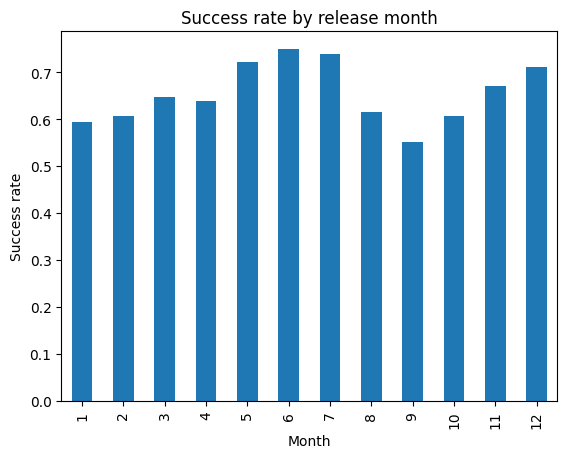

In [ ]:
movies['release_date'] = pd.to_datetime(movies['release_date'])
movies['release_month'] = movies['release_date'].dt.month

# quick chart
movies.groupby('release_month')['success'].mean().plot(kind='bar')
plt.title('Success rate by release month')
plt.xlabel('Month')
plt.ylabel('Success rate')
plt.show()

In [ ]:
print(movies.columns.tolist())

['budget', 'revenue', 'runtime', 'popularity', 'release_date', 'genres', 'vote_average', 'vote_count', 'cast', 'crew', 'success', 'genre_list', 'Drama', 'Comedy', 'Thriller', 'Action', 'Adventure', 'Romance', 'Crime', 'Science Fiction', 'Family', 'Fantasy', 'release_month']


In [ ]:
movies['director'] = movies['crew'].apply(get_director)
movies['cast_list'] = movies['cast'].apply(get_top_cast)
#ideja je če je bolj izkušen, potem je potencialno boljši film
director_counts = movies['director'].value_counts() #koliko filmov ima vsak director
movies['director_experience'] = movies['director'].map(director_counts)

from collections import Counter
all_cast = [actor for sublist in movies['cast_list'] for actor in sublist] #flattening
cast_counts = Counter(all_cast)

def cast_fame_score(cast_list):
    if not cast_list:
        return 0
    return sum(cast_counts[actor] for actor in cast_list) / len(cast_list)

movies['cast_fame'] = movies['cast_list'].apply(cast_fame_score)

In [ ]:
#handling missing values
movies['director_experience'] = movies['director_experience'].fillna(1)
movies['cast_fame'] = movies['cast_fame'].fillna(0)

In [ ]:
feature_cols = ['budget', 'runtime', 'popularity', 'vote_average',
                'vote_count', 'release_month', 'director_experience', 'cast_fame'] + top_genres

X = movies[feature_cols] #input
y = movies['success'] #predicction

print(X.shape)
print(y.value_counts())

(3229, 18)
success
1    2110
0    1119
Name: count, dtype: int64


In [ ]:
#splitting data to train and test
from sklearn.model_selection import train_test_split #library for ML

X_train, X_test, y_train, y_test = train_test_split( #x -input learn,test , y_train-right train and test
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 2583
Testing samples:  646


In [ ]:
#scaling features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# fill missing values, again, recheck
movies['director_experience'] = movies['director_experience'].fillna(1)
movies['cast_fame'] = movies['cast_fame'].fillna(0)

# rebuild X and y after filling
X = movies[feature_cols]
y = movies['success']

In [ ]:
print(movies.columns.tolist())
import numpy as np
print(np.isnan(X_train_scaled).sum())


['budget', 'revenue', 'runtime', 'popularity', 'release_date', 'genres', 'vote_average', 'vote_count', 'cast', 'crew', 'success', 'genre_list', 'Drama', 'Comedy', 'Thriller', 'Action', 'Adventure', 'Romance', 'Crime', 'Science Fiction', 'Family', 'Fantasy', 'release_month', 'director', 'cast_list', 'director_experience', 'cast_fame']
0


In [ ]:
#logistic regression - 0/1
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_model = LogisticRegression(random_state=42, max_iter=1000) #ustvari model
lr_model.fit(X_train_scaled, y_train) #learn

y_pred_lr = lr_model.predict(X_test_scaled) #predict

print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.3f}") # TP + TN / vse
print(f"Precision: {precision_score(y_test, y_pred_lr):.3f}") #od vseh napovedanih, koliko je bilo res uspesnih,TP / (TP + FP)
print(f"Recall:    {recall_score(y_test, y_pred_lr):.3f}") #TP / (TP + FN)
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.3f}") #kombinacija precision and recall

=== Logistic Regression ===
Accuracy:  0.731
Precision: 0.780
Recall:    0.814
F1 Score:  0.797


In [ ]:
#random forest - mini models
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train) #learn

y_pred_rf = rf_model.predict(X_test_scaled) #predict

print("=== Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.3f}")
#boljsi v skoraj vseh metrikah

=== Random Forest ===
Accuracy:  0.766
Precision: 0.785
Recall:    0.881
F1 Score:  0.830


In [ ]:
#ann
from sklearn.neural_network import MLPClassifier

ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=1000,  # increase from 500 to 1000
    random_state=42
)
ann_model.fit(X_train_scaled, y_train)

y_pred_ann = ann_model.predict(X_test_scaled)

print("=== ANN (MLP) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_ann):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_ann):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_ann):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_ann):.3f}")
#slabi rezultati, morda premajhen dataset, niso kompleksni vzorci, tuning....

=== ANN (MLP) ===
Accuracy:  0.718
Precision: 0.796
Recall:    0.761
F1 Score:  0.778


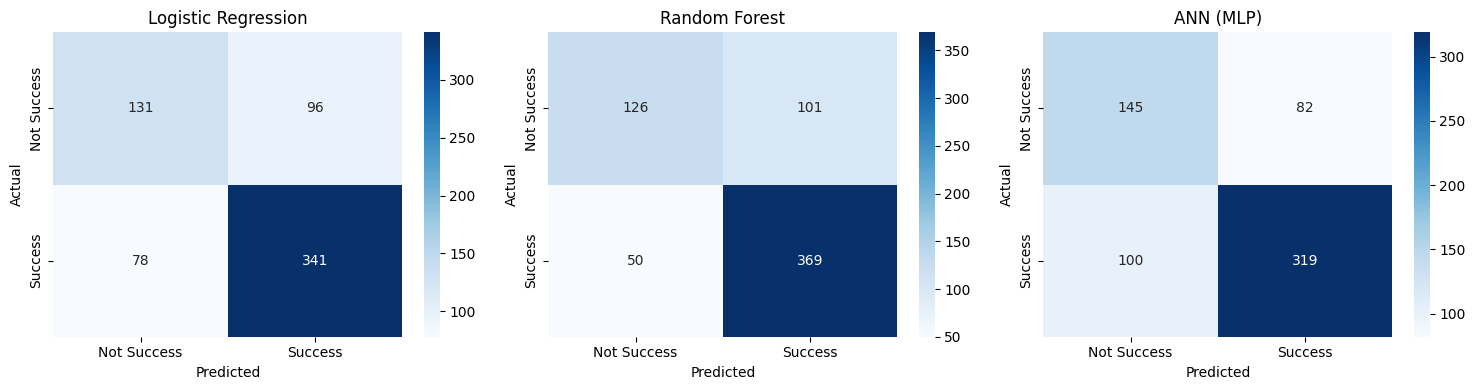

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("ANN (MLP)", y_pred_ann),
]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Success', 'Success'],
                yticklabels=['Not Success', 'Success'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

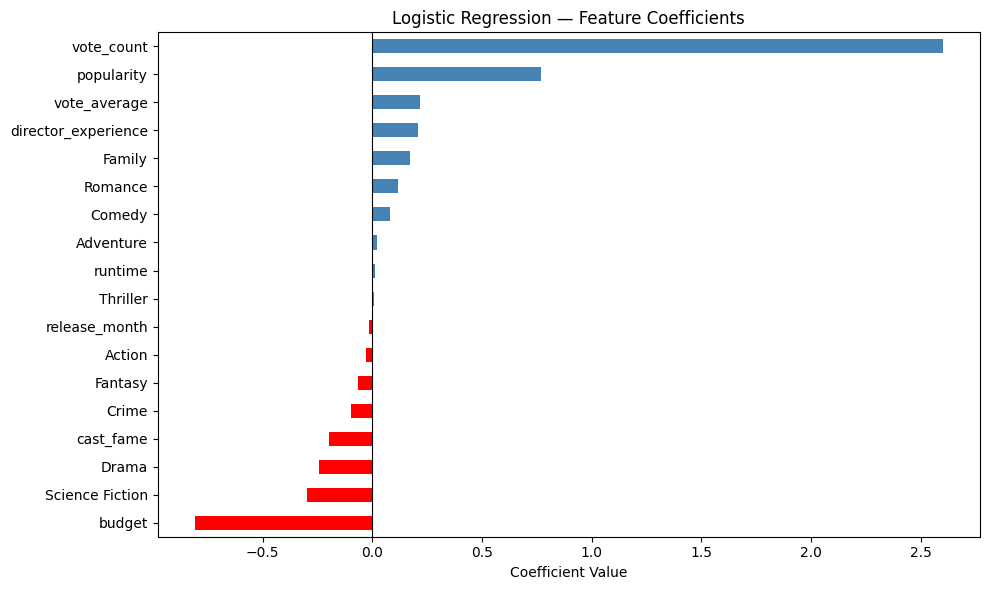

In [ ]:
import numpy as np

coefs = lr_model.coef_[0]
feat_importance_lr = pd.Series(coefs, index=feature_cols).sort_values()

plt.figure(figsize=(10, 6))
colors = ['red' if v < 0 else 'steelblue' for v in feat_importance_lr]
feat_importance_lr.plot(kind='barh', color=colors)
plt.title('Logistic Regression — Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('lr_feature_importance.png', dpi=150)
plt.show()

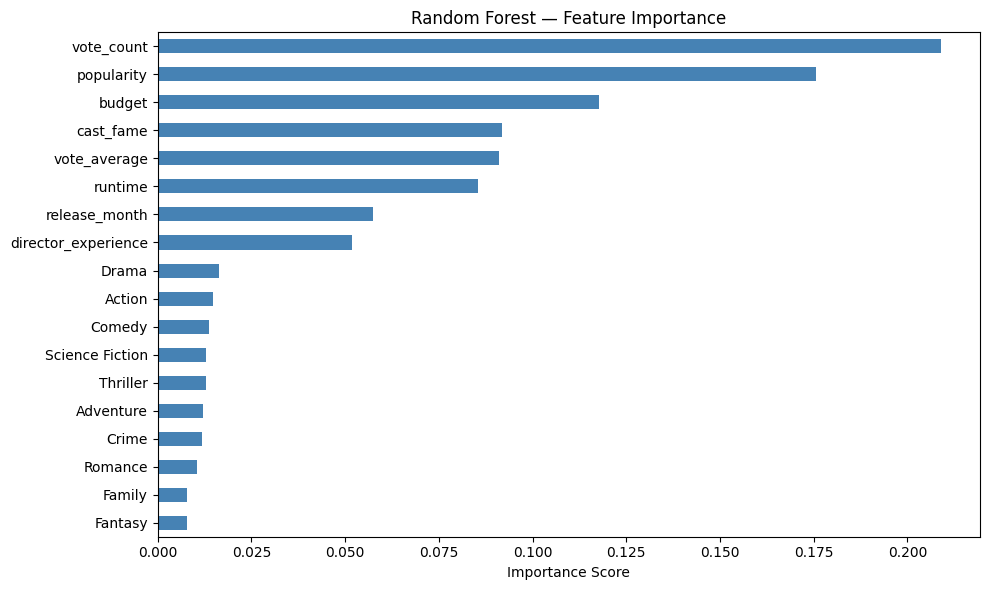

In [ ]:
feat_importance_rf = pd.Series(
    rf_model.feature_importances_, index=feature_cols
).sort_values()

plt.figure(figsize=(10, 6))
feat_importance_rf.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

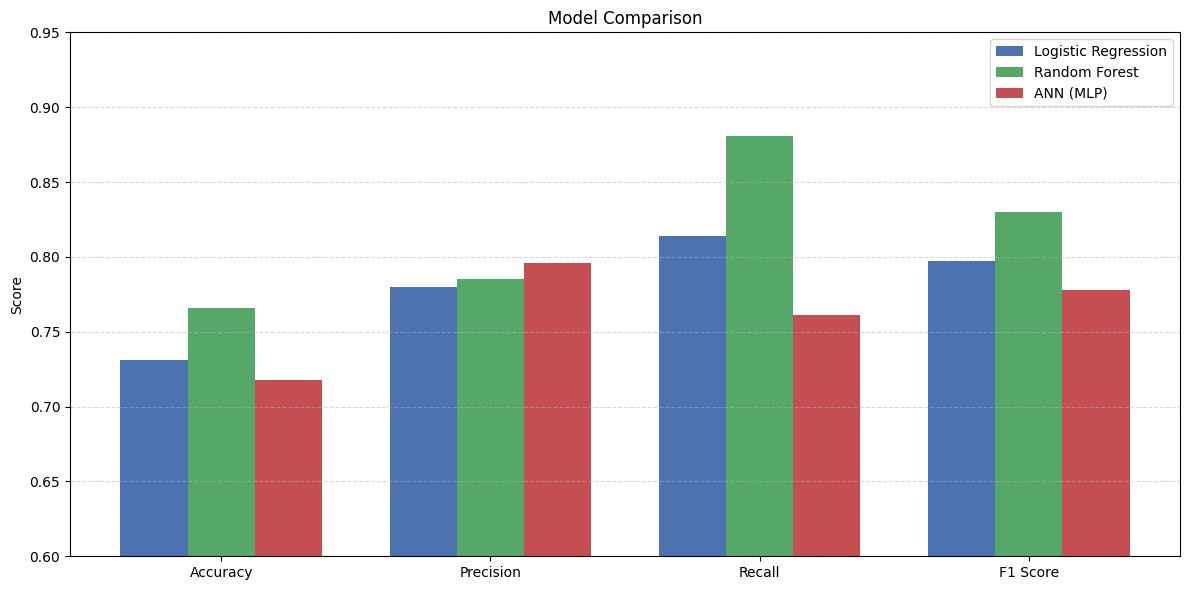

In [ ]:
metrics = {
    'Accuracy':  [0.731, 0.766, 0.718],
    'Precision': [0.780, 0.785, 0.796],
    'Recall':    [0.814, 0.881, 0.761],
    'F1 Score':  [0.797, 0.830, 0.778],
}

x = np.arange(len(metrics))
width = 0.25
model_names = ['Logistic Regression', 'Random Forest', 'ANN (MLP)']
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [metrics[m][i] for m in metrics]
    ax.bar(x + i * width, vals, width, label=name, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics.keys())
ax.set_ylim(0.6, 0.95)
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [22]:
print("=====================CHANGES=======================")
print("=====================CLEAN VERSION=======================")
print("1. split 2. feature engineering 3. X/y selection 4. scaling 5. model 6. evaluation")

=====================CHANGES=======================
=====================CLEAN VERSION=======================
1. split 2. feature engineering 3. X/y selection 4. scaling 5. model 6. evaluation


In [53]:
import pandas as pd
import numpy as np
import ast

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [5]:
from google.colab import files
uploaded = files.upload()
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

credits = credits.rename(columns={'movie_id': 'id'})
movies = movies.merge(credits, on='id')

print(movies.shape)

Saving tmdb_5000_credits.csv to tmdb_5000_credits.csv
Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv
(4803, 23)


In [6]:
movies = movies[movies['budget'] > 0]
movies = movies[movies['revenue'] > 0]
movies = movies.dropna(subset=['runtime', 'release_date'])

In [7]:
movies['success'] = (movies['revenue'] >= 1.5 * movies['budget']).astype(int)

In [8]:
X = movies.copy()
y = movies['success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
def get_director(crew_str):
    try:
        crew = ast.literal_eval(crew_str)
        for m in crew:
            if m['job'] == 'Director':
                return m['name']
    except:
        return None
    return None

X_train['director'] = X_train['crew'].apply(get_director)
X_test['director'] = X_test['crew'].apply(get_director)

director_counts = X_train['director'].value_counts()

X_train['director_experience'] = X_train['director'].map(director_counts)
X_test['director_experience'] = X_test['director'].map(director_counts).fillna(1)

In [10]:
def get_top_cast(cast_str):
    try:
        cast = ast.literal_eval(cast_str)
        return [m['name'] for m in cast if m['order'] < 3]
    except:
        return []

X_train['cast_list'] = X_train['cast'].apply(get_top_cast)
X_test['cast_list'] = X_test['cast'].apply(get_top_cast)

all_cast = [a for sub in X_train['cast_list'] for a in sub]
cast_counts = Counter(all_cast)

def cast_fame_score(cast_list):
    if not cast_list:
        return 0
    return sum(cast_counts[a] for a in cast_list) / len(cast_list)

X_train['cast_fame'] = X_train['cast_list'].apply(cast_fame_score)
X_test['cast_fame'] = X_test['cast_list'].apply(cast_fame_score)

In [11]:
def get_genres(g):
    try:
        return [x['name'] for x in ast.literal_eval(g)]
    except:
        return []

X_train['genre_list'] = X_train['genres'].apply(get_genres)
X_test['genre_list'] = X_test['genres'].apply(get_genres)

all_genres = [g for sub in X_train['genre_list'] for g in sub]
top_genres = [g for g, _ in Counter(all_genres).most_common(10)]

for g in top_genres:
    X_train[g] = X_train['genre_list'].apply(lambda x: int(g in x))
    X_test[g] = X_test['genre_list'].apply(lambda x: int(g in x))

In [12]:
feature_cols = [
    'budget', 'runtime', 'popularity', 'vote_average',
    'vote_count', 'director_experience', 'cast_fame'
] + top_genres

X_train = X_train[feature_cols]
X_test = X_test[feature_cols]

In [15]:
X_train['director_experience'] = X_train['director_experience'].fillna(1)
X_test['director_experience'] = X_test['director_experience'].fillna(1)

X_train['cast_fame'] = X_train['cast_fame'].fillna(0)
X_test['cast_fame'] = X_test['cast_fame'].fillna(0)

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [46]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [47]:
# ANN (MLP)
ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=1000,
    random_state=42,
    early_stopping=True
)

ann.fit(X_train_scaled, y_train)
y_pred_ann = ann.predict(X_test_scaled)

In [48]:
def evaluate(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:", round(recall_score(y_true, y_pred), 3))
    print("F1:", round(f1_score(y_true, y_pred), 3))

In [49]:
evaluate("Logistic Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, pred_rf)
evaluate("ANN", y_test, pred_ann)


=== Logistic Regression ===
Accuracy: 0.738
Precision: 0.784
Recall: 0.823
F1: 0.803

=== Random Forest ===
Accuracy: 0.772
Precision: 0.794
Recall: 0.876
F1: 0.833

=== ANN ===
Accuracy: 0.745
Precision: 0.777
Recall: 0.85
F1: 0.812


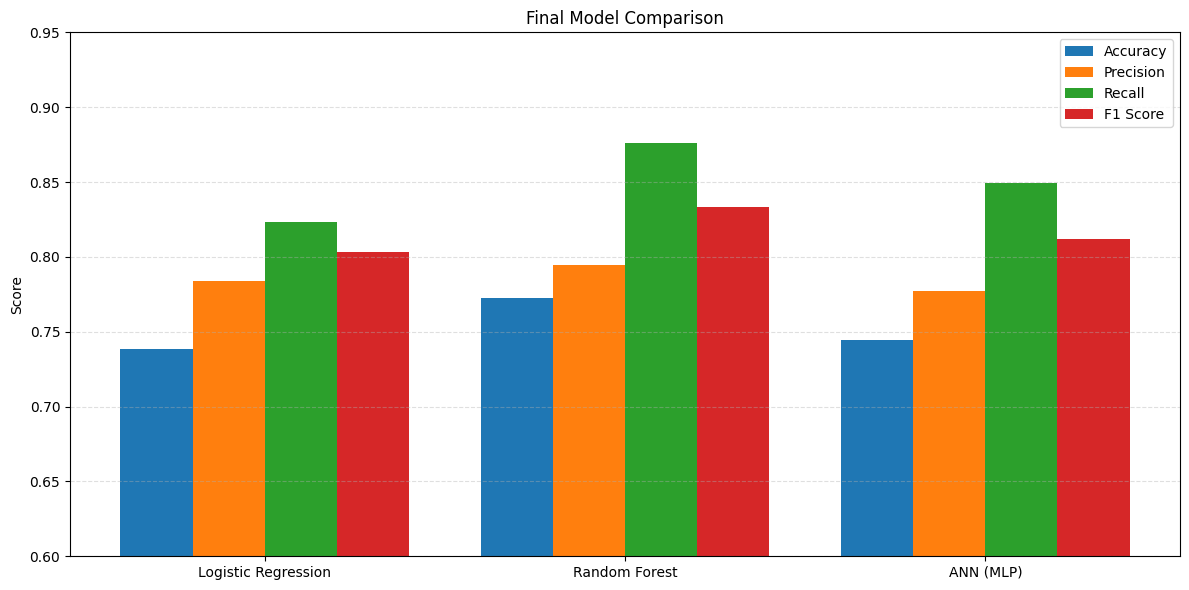

In [52]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic Regression', 'Random Forest', 'ANN (MLP)']

metrics = {
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ann),
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_ann),
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ann),
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ann),
    ],
}

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

for i, (metric_name, values) in enumerate(metrics.items()):
    ax.bar(x + i * width, values, width, label=metric_name)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.set_ylim(0.6, 0.95)
ax.set_title("Final Model Comparison")
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

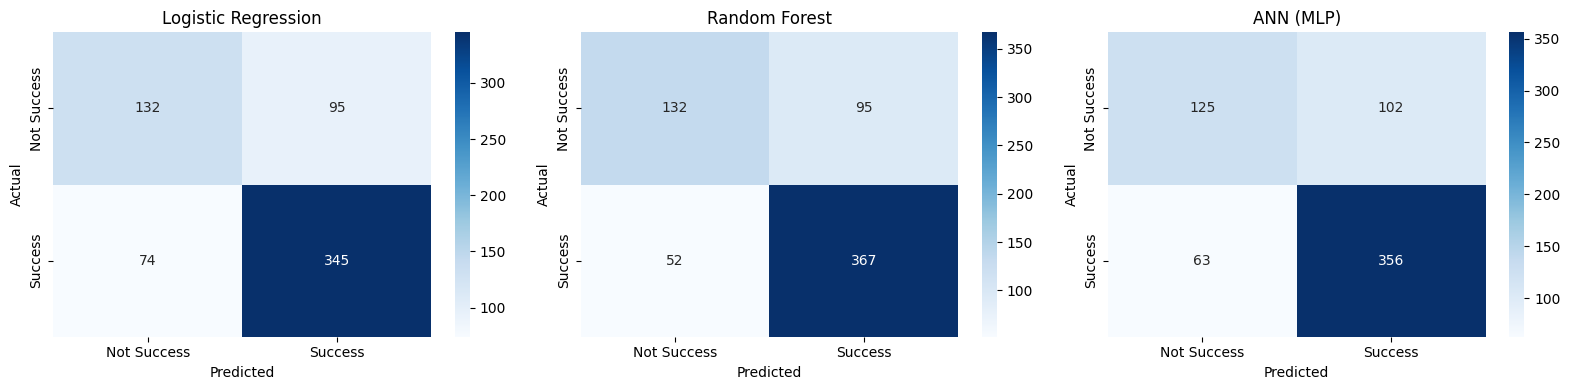

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("ANN (MLP)", y_pred_ann),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Not Success', 'Success'],
        yticklabels=['Not Success', 'Success']
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()